# PyDESeq2 differential expression analysis: ERBB2 OE vs WT, sham and MI

**Data**

3 animals for each experimental group were used (Control, PE, IGF1).
NRVCMs were treated with PE or IGF1 for 48h.
https://linkinghub.elsevier.com/retrieve/pii/S2211124720310767

**Design**
The samplesheet has one factors, `condition` (Control / PE / IGF1) and the model `~ condition` is fitted **once** on all 9 samples, so dispersions are estimated with all the data. Only the contrast IGF1 vs Control is then extracted.

log2FC is always `IGF1 / Control`, so a positive value means higher in IGF1-treated cells. Each contrast is exported as a table, ready for the CORNETO notebook.

**Inputs**
- Raw (un-normalised) counts, genes x samples (nf-core `salmon.merged.gene_counts.tsv`). Salmon counts are non-integer and are rounded.
- `samplesheet.csv` with `sample` and `condition` columns.

**Conventions kept from the AXL analysis**
- Genes with fewer than 30 reads across all samples are removed before fitting.
- Significance threshold: adjusted p < 0.05.
- `stat` is the Wald statistic from the un-shrunk model (the CORNETO notebook runs decoupler on `stat`). LFC shrinkage is not applied.

**Things to check**
- Gene identifiers: the CORNETO notebook expects **rat gene symbols**. nf-core tables have `gene_id` (Ensembl) and `gene_name`; the loader below uses `gene_name` as index.
- Use the PCA in step 5 to spot outlier samples. Document any exclusion in the config cell rather than editing the count file.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pydeseq2
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

print('pydeseq2', pydeseq2.__version__)

pydeseq2 0.5.4


## 1. Configuration (edit this cell only)

In [8]:
root_dir = '/mnt/sds-hd/sd22b002/projects/ines/axl_networks'
project_dir = f'{root_dir}/results/igf1'    # nf-core run output

dataset_id = 'GSE153763_IGF1'   # prefix for output file names
counts_file = f'{project_dir}/star_salmon/salmon.merged.gene_counts.tsv'
counts_sep = '\t'
counts_orientation = 'genes_x_samples'   # or 'samples_x_genes'
gene_name_col = 'gene_name'      # nf-core: symbols column next to the Ensembl gene_id index; None if absent

# --- sample annotation ---------------------------------------------------
metadata_file = f'{root_dir}/data/downloads/GSE153763_IGF1/samplesheet.csv'
metadata_sep = ','
metadata_index_col = 'sample'    # column with sample IDs matching the count matrix columns
group_col = 'condition'

# name -> (numerator group, reference group); log2FC = numerator / reference
contrasts = {
    'IGF1_vs_Control': ('IGF1', 'Control')
}
covariates = []                  # extra design columns present in the metadata, e.g. ['batch']
exclude_samples = []             # sample IDs to drop (document why, e.g. PCA outlier)

# --- model / filtering ---------------------------------------------------
min_total_counts = 30            # same filter as the AXL analysis (sum over all samples)
alpha = 0.05
n_cpus = 2

# --- output --------------------------------------------------------------
results_dir = f'{root_dir}/results/igf1/pydeseq2'
figures_dir = f'{root_dir}/figures'
os.makedirs(results_dir, exist_ok=True)
os.makedirs(figures_dir, exist_ok=True)

## 2. Load counts and metadata

In [9]:
counts = pd.read_csv(counts_file, sep=counts_sep, index_col=0)
if counts_orientation == 'genes_x_samples':
    # nf-core tables: Ensembl gene_id is the index, gene_name a separate column
    if gene_name_col is not None and gene_name_col in counts.columns:
        counts = counts.set_index(gene_name_col)
    counts = counts.T          # PyDESeq2 wants samples x genes
elif counts_orientation != 'samples_x_genes':
    raise ValueError("counts_orientation must be 'genes_x_samples' or 'samples_x_genes'")
counts.index = counts.index.astype(str)
counts.columns = counts.columns.astype(str)

# sample annotation, with the two factors merged into one group factor
metadata = pd.read_csv(metadata_file, sep=metadata_sep, index_col=metadata_index_col)
metadata.index = metadata.index.astype(str)

# consistency checks
missing_meta = counts.index.difference(metadata.index)
missing_counts = metadata.index.difference(counts.index)
if len(missing_meta) or len(missing_counts):
    print('In counts but not metadata (dropped):', list(missing_meta))
    print('In metadata but not counts (dropped):', list(missing_counts))
keep = counts.index.intersection(metadata.index).difference(exclude_samples)
counts, metadata = counts.loc[keep], metadata.loc[keep]

# duplicated gene symbols: sum them
if counts.columns.duplicated().any():
    print(f'Summing {counts.columns.duplicated().sum()} duplicated gene columns')
    counts = counts.T.groupby(level=0).sum().T

# raw counts must be non-negative
counts = counts.apply(pd.to_numeric)
if counts.isna().any().any() or (counts < 0).any().any():
    raise ValueError('Counts contain NaN or negative values')
if (counts % 1 != 0).any().any():
    print('Non-integer counts found (salmon expected counts): rounding')
counts = counts.round().astype(int)

metadata = metadata[[group_col] + covariates].copy()
levels = set(metadata[group_col].unique())
needed = {g for pair in contrasts.values() for g in pair}
assert needed <= levels, f'missing groups: {needed - levels}; levels found: {levels}'

print(f'{counts.shape[0]} samples x {counts.shape[1]} genes')
print(metadata.groupby(group_col).size())

Summing 455 duplicated gene columns
Non-integer counts found (salmon expected counts): rounding
9 samples x 42905 genes
condition
Control    3
IGF1       3
PE         3
dtype: int64


## 3. Filter low-count genes

In [10]:
# Keep only the groups used in the contrasts
metadata = metadata[metadata[group_col].isin(needed)]
counts = counts.loc[metadata.index]

gene_totals = counts.sum(axis=0)
n_before = counts.shape[1]
counts = counts.loc[:, gene_totals >= min_total_counts]
print(f'Genes kept: {counts.shape[1]} / {n_before} (>= {min_total_counts} reads across samples)')

Genes kept: 17127 / 42905 (>= 30 reads across samples)


## 4. Fit the model and run the Wald test

In [11]:
design = '~' + ' + '.join(covariates + [group_col])
print('Design:', design)

try:   # pydeseq2 >= 0.5
    dds = DeseqDataSet(counts=counts, metadata=metadata, design=design,refit_cooks=True)
except TypeError:   # older releases use design_factors
    dds = DeseqDataSet(counts=counts, metadata=metadata, design_factors=covariates + [group_col], refit_cooks=True)
dds.deseq2()   # fitted once; all contrasts below reuse this fit

results = {}
for name, (num, ref) in contrasts.items():
    stat_res = DeseqStats(dds, contrast=[group_col, num, ref], alpha=alpha)
    stat_res.summary()
    results[name] = stat_res.results_df.copy()

Design: ~condition
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 11.78 seconds.

Fitting dispersion trend curve...
... done in 0.31 seconds.

Fitting MAP dispersions...
... done in 13.64 seconds.

Fitting LFCs...
... done in 8.54 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: condition IGF1 vs Control
                   baseMean  log2FoldChange     lfcSE      stat        pvalue  \
gene_name                                                                       
1700001K19Rikl     5.784447       -0.509233  0.751570 -0.677559  4.980515e-01   
2010315B03Rikl   220.044023       -0.116036  0.135765 -0.854681  3.927280e-01   
2310002L09Rikl   171.348994        1.155977  0.161552  7.155452  8.339778e-13   
2510039O18Rikl  1432.423411       -0.154008  0.069086 -2.229226  2.579889e-02   
2610008E11Rikl  1100.455099        0.012254  0.075680  0.161917  8.713715e-01   
...                     ...             ...       ...       ...           ...   
Zyg11a             8.647344        0.001687  0.606996  0.002780  9.977822e-01   
Zyg11b          3465.677009        0.067561  0.066759  1.012009  3.115339e-01   
Zyx             4909.195388       -0.170661  0.230030 -0.741907  4.581438e-01   
Zzef1           2701.080053        0.085470  

... done in 3.45 seconds.



In [12]:
results['IGF1_vs_Control'].sort_values('padj').head(10)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_name,,,,,,
Myom2,36030.155646,-2.505654,0.062380,-40.167435,0.000000e+00,0.000000e+00
Kcnip2,3995.226303,-3.361730,0.087322,-38.498136,0.000000e+00,0.000000e+00
Ckmt2,921.634587,2.956864,0.090136,32.804453,5.087165e-236,2.733164e-232
Scd2,8375.788696,1.879721,0.060420,31.111016,1.709127e-212,6.886925e-209
Eno3,3508.930141,1.920921,0.067793,28.335119,1.276793e-176,4.115870e-173
Pla2g7,1674.821853,-2.089693,0.076517,-27.310218,3.207764e-164,8.617123e-161
Txnip,22111.487354,-1.415875,0.059686,-23.721996,2.138382e-124,4.923777e-121
Nek2,1320.360107,1.855650,0.080165,23.147964,1.524047e-118,3.070574e-115
Ccnb1,1593.431372,1.944063,0.086427,22.493832,4.769735e-112,8.542066e-109


## 5. QC: PCA of normalised counts and result summary

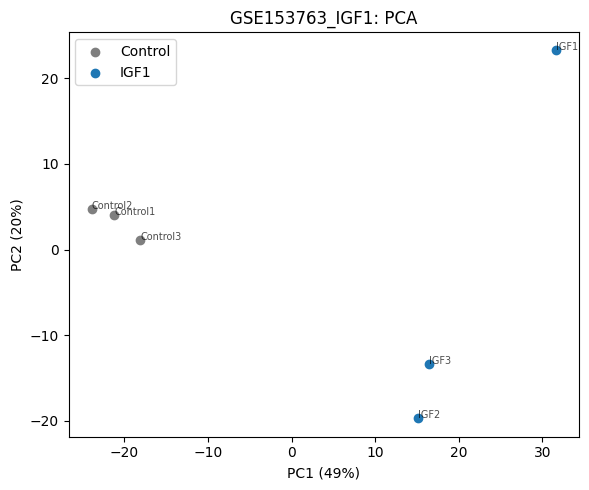

[IGF1_vs_Control] IGF1 vs Control: 5839 significant genes (padj < 0.05; 3176 up, 2663 down); padj NA: 1009


In [13]:
# PCA on log2(normalised counts + 1), top 1000 most variable genes, all groups
norm = pd.DataFrame(dds.layers['normed_counts'], index=counts.index, columns=counts.columns)
logn = np.log2(norm + 1)
top = logn.var(axis=0).sort_values(ascending=False).index[:1000]
X = logn[top] - logn[top].mean(axis=0)
U, S, Vt = np.linalg.svd(X.values, full_matrices=False)
pcs = U * S
var_expl = S**2 / np.sum(S**2)

palette = {'hOSM': 'tab:blue', 'mOSM': 'tab:cyan', 'mLIF': 'tab:orange', 'Control': 'tab:gray'}
fig, ax = plt.subplots(figsize=(6, 5))
for grp in sorted(metadata[group_col].unique()):
    idx = (metadata[group_col] == grp).values
    ax.scatter(pcs[idx, 0], pcs[idx, 1], label=grp, color=palette.get(grp))
for i, name in enumerate(counts.index):
    ax.annotate(name, (pcs[i, 0], pcs[i, 1]), fontsize=7, alpha=0.7)
ax.set_xlabel(f'PC1 ({var_expl[0]:.0%})')
ax.set_ylabel(f'PC2 ({var_expl[1]:.0%})')
ax.set_title(f'{dataset_id}: PCA')
ax.legend()
plt.tight_layout()
plt.savefig(f'{figures_dir}/{dataset_id}_pca.png', dpi=200)
plt.show()

for name, res in results.items():
    num, ref = contrasts[name]
    sig = res['padj'] < alpha
    print(f'[{name}] {num} vs {ref}: {sig.sum()} significant genes (padj < {alpha}; '
          f'{(sig & (res.log2FoldChange > 0)).sum()} up, {(sig & (res.log2FoldChange < 0)).sum()} down); '
          f'padj NA: {res.padj.isna().sum()}')

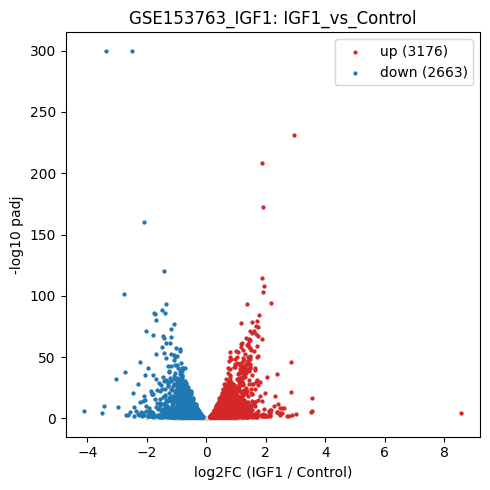

In [14]:
# Volcano plots, one panel per contrast
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 5), squeeze=False)
for ax, (name, res) in zip(axes[0], results.items()):
    num, ref = contrasts[name]
    v = res.dropna(subset=['padj']).copy()
    v['neglog10p'] = -np.log10(v['padj'].clip(lower=1e-300))
    up = (v.padj < alpha) & (v.log2FoldChange > 0)
    down = (v.padj < alpha) & (v.log2FoldChange < 0)
    ax.scatter(v.log2FoldChange, v.neglog10p, s=4, color='lightgrey')
    ax.scatter(v.log2FoldChange[up], v.neglog10p[up], s=4, color='tab:red', label=f'up ({up.sum()})')
    ax.scatter(v.log2FoldChange[down], v.neglog10p[down], s=4, color='tab:blue', label=f'down ({down.sum()})')
    ax.set_xlabel(f'log2FC ({num} / {ref})')
    ax.set_ylabel('-log10 padj')
    ax.set_title(f'{dataset_id}: {name}')
    ax.legend()
plt.tight_layout()
plt.savefig(f'{figures_dir}/{dataset_id}_volcano.png', dpi=200)
plt.show()

## 6. Export

Writes one table per contrast, `results/<dataset_id>_<contrast>_deseq2.csv` (e.g. `GSE144391_ERBB2_sham_deseq2.csv`, `GSE144391_ERBB2_MI_deseq2.csv`), in the same layout as the AXL DESeq2 table (first column `Gene.name`), plus one settings file.

In [15]:
cols = ['Gene.name', 'baseMean', 'log2FoldChange', 'lfcSE', 'stat', 'pvalue', 'padj']
settings = []
for name, res in results.items():
    num, ref = contrasts[name]
    out = res.rename_axis('Gene.name').reset_index()
    out = out[cols].sort_values('padj', na_position='last')
    out_file = f'{results_dir}/{dataset_id}_{name}_deseq2.csv'
    out.to_csv(out_file, index=False)
    print('Saved', out_file, out.shape)
    settings.append({
        'dataset_id': dataset_id, 'contrast_name': name, 'design': design,
        'contrast': f'{num} vs {ref}',
        'n_numerator': int((metadata[group_col] == num).sum()),
        'n_reference': int((metadata[group_col] == ref).sum()),
        'excluded_samples': ','.join(exclude_samples),
        'min_total_counts': min_total_counts, 'n_genes_tested': counts.shape[1],
        'n_sig_padj_lt_alpha': int((res.padj < alpha).sum()), 'pydeseq2': pydeseq2.__version__,
    })

# run settings next to the results, for the cross-dataset comparison
pd.DataFrame(settings).to_csv(f'{results_dir}/{dataset_id}_deseq2_settings.csv', index=False)
pd.DataFrame(settings)

Saved /mnt/sds-hd/sd22b002/projects/ines/axl_networks/results/igf1/pydeseq2/GSE153763_IGF1_IGF1_vs_Control_deseq2.csv (17127, 7)


,dataset_id,contrast_name,design,contrast,n_numerator,n_reference,excluded_samples,min_total_counts,n_genes_tested,n_sig_padj_lt_alpha,pydeseq2
0,GSE153763_IGF1,IGF1_vs_Control,~condition,IGF1 vs Control,3,3,,30,17127,5839,0.5.4
